Modified from "Using Deep Learning for Flexible and Scalable Earthquake Forecasting"  
Reference: [Zenodo](https://zenodo.org/records/8161777)

In [28]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path
import torch
import src  
import matplotlib.pyplot as plt
from src.utils.utils import set_seed
import src.data.catalog as catalog
import src.catalogs as catalogs
import functools
import os
import importlib
sys.path.append(str(Path.cwd().parent))
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
set_seed(0) 

In [29]:
checkpoint_dir = Path("../checkpoints/etas_20260103-143159")  #
# checkpoints/etas_20260103-143454
# checkpoints/etas_20260103-143159
checkpoint_path = checkpoint_dir / "best_model_1.pth"

## Loading a trained model

In [30]:
from src.models.builders import ModelBuilder
from src.train.config_setup import load_args_from_checkpoint,load_model_from_checkpoint

check_point = torch.load(checkpoint_path,weights_only=False)    
args = load_args_from_checkpoint(None, check_point)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_builder = ModelBuilder.by_name(args.model.lower())()
model = model_builder(args, device)
model,_,_ = load_model_from_checkpoint(model, check_point)
# model.set_attn_type("flash")
# model.set_attn_dropout(0)
model = torch.compile(model)
model.eval() 

load_specific_parts: None
Checkpoint loaded: <All keys matched successfully>
hyperparameters: {'model': 'etas', 'num_event_types': 1, 'pad_token_id': 1, 'task_type': 'tpp', 'base_rate_init': 0.26, 'batch_size': 32, 'accumulation_steps': 1, 'warmup_ratio': 0.1, 'learning_rate': 0.01, 'weight_decay': 0.005, 'scheduler_factor': None, 'scheduler_patience': None, 'scheduler_threshold': None, 'scheduler_min_lr': 1e-06, 'scheduler_type': 'step_warmup', 'step_lr_step_size_ratio': 0.2, 'step_lr_gamma': 0.8, 'dim': 1, 'epochs': 1000, 'save_dir': 'checkpoints/etas_20260103-143159', 'cuda_id': '0', 'dataset': 'ChuanDian', 'seed': 0, 'minibatch_training': True, 'split_by_time': True, 'time_order': ['train', 'val', 'test'], 'cuda': True, 'tau_mean': 1.6484907865524292, 'tau_min': 2.3148149921325967e-06, 'tau_max': 32.8729133605957, 'tau_q05': 0.5829246044158936, 'tau_q025': 0.0008729455876164138, 'mag_mean': 3.5779941082000732, 'time_max': 16436.0, 'time_mean': 8854.9658203125, 'mag_completeness': 3

OptimizedModule(
  (_orig_mod): ETAS()
)

In [31]:
model.print_params()

ETAS model parameters:
  p = 0.9924443566544227
  c = 0.014830445521107778
  mu = 0.1250689905515746
  k = 0.016082051054796556
  K = -2.0618253762756145
  alpha = 0.6331838986025086
  alpha_e = 1.4579598060459897
  b = 0.7449380159378052
  M_c = 3.0
  M_m = 10.0


## Loading the catalog

In [32]:
# args.dataset = "ChinaArray" 
catalog_ds_class = catalog.Catalog.by_name(f"{args.dataset}-Standard")
catalog_ds = catalog_ds_class(root_dir=f'../data/{args.dataset}/raw')

Loading existing catalog from /root/autodl-tmp/chuandian_eq/data/ChuanDian/raw.


In [33]:
catalog_ds.full_sequence

Sequence(
  inter_times: [11581],
  arrival_times: [11580],
  t_start: 0.0,
  t_end: 18771.0,
  t_nll_start: 0.0,
  mag: [11580],
  loc: [11580, 2],
  depth: [11580]
)

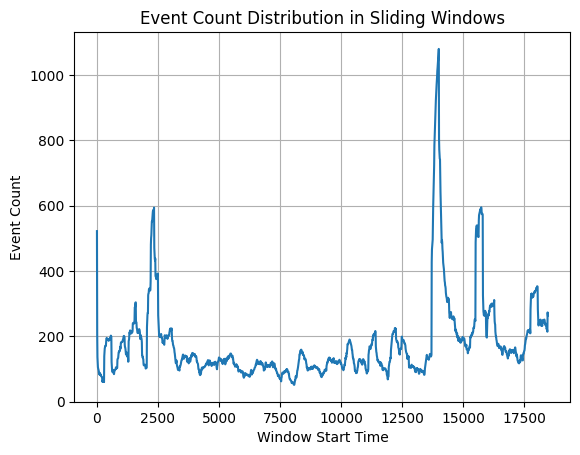

In [34]:
window_size = 300
stride = 10
arrival_times = catalog_ds.full_sequence.arrival_times
max_time = arrival_times.max().item()
window_starts = torch.arange(0, max_time - window_size + stride, stride)
counts = torch.zeros(len(window_starts), dtype=torch.int32)

for i, start in enumerate(window_starts):
    end = start + window_size
    mask = (arrival_times >= start) & (arrival_times < end)
    counts[i] = mask.sum()
plt.plot(window_starts, counts)
plt.xlabel('Window Start Time')
plt.ylabel('Event Count')
plt.title('Event Count Distribution in Sliding Windows')
plt.grid(True)
plt.show()

In [35]:
# b_seq = model.compute_b_value(catalog_ds.full_sequence.to(device),True)
# plt.plot(b_seq.squeeze().detach().cpu().numpy())
# plt.savefig(checkpoint_dir/'b_pred.png')
# data = b_seq.squeeze().detach().cpu().numpy()
# smooth = pd.Series(data).rolling(window=500, min_periods=1).mean()
# plt.plot(smooth)
# plt.savefig(checkpoint_dir/'b_pred_smooth.png')

## Prepare the data

We trained the TPP model using the `train` and `val` sequences. Now we will use the unseen section of the `test` sequence (in orange) to evaluate forecasting performance of the model.

<Axes: xlabel='Arrival time (days)', ylabel='Magnitude'>

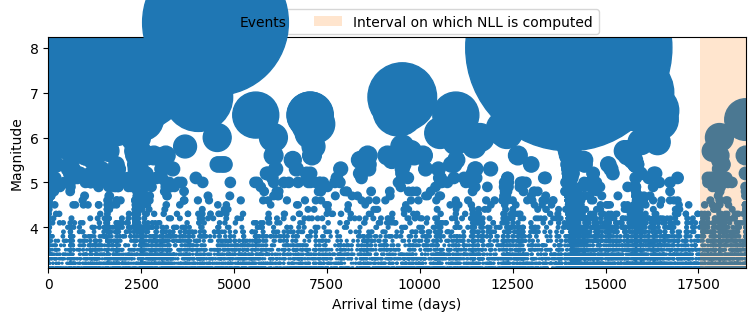

In [36]:
from src.utils.visualization import visualize_sequence
test_seq = catalog_ds.test[0]
train_seq = catalog_ds.train[0]
visualize_sequence(test_seq, show_nll=True)

We would like to generate a 30-day forecast for the interval `[13000, 13030]`. For this, we select two subsequences:
- `past_seq`: Contains events from `[0, 13000]`, is used to condition the model
- `observed_seq`: Contains actually observed events from `[13000, 13030]`.

In [37]:
t_forecast = 18000 # 4000 13000
duration = 30 # 7 30
num_samples = 10000 # 10000

# Past events that we condition on
past_seq = test_seq.get_subsequence(0, t_forecast) #  3500
observed_seq = test_seq.get_subsequence(t_forecast, t_forecast + duration)

## Generate the forecast

In [38]:
past_seq.float()

Sequence(
  inter_times: [10837],
  arrival_times: [10836],
  t_start: 0.0,
  t_end: 18000.0,
  t_nll_start: 17532.0,
  mag: [10836],
  loc: [10836, 2],
  depth: [10836]
)

In [39]:
past_batch = src.data.Batch.from_list([past_seq])

In [40]:
torch.mean(past_batch.inter_times)

tensor(1.6610)

In [41]:
if torch.cuda.is_available():
    model.to('cuda:0')
    past_seq.to('cuda:0')

In [42]:
# torch.backends.cudnn.enabled = False

In [43]:
model.print_params()

ETAS model parameters:
  p = 0.9924443566544227
  c = 0.014830445521107778
  mu = 0.1250689905515746
  k = 0.016082051054796556
  K = -2.0618253762756145
  alpha = 0.6331838986025086
  alpha_e = 1.4579598060459897
  b = 0.7449380159378052
  M_c = 3.0
  M_m = 10.0


In [44]:
set_seed(3) 
model.eval()  # Set the model to evaluation mode

all_forecasts = []
samples_per_batch = 10000
for _ in range(num_samples // samples_per_batch):
    # forecast = model.sample_with_cache(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True)
    # forecast = model.sample(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True, max_sample_len=4000)
    forecast = model.sample(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True)
    # forecast = model.sample_gpu_parallel(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True, dtype=torch.float32)
    all_forecasts.extend(forecast)

  0%|          | 0/10000 [00:00<?, ?it/s]

`forecast` is a list, where each element is a `eq.data.Sequence` that represents a possible continuation of the catalog over the interval `[13000, 13030]`.

With the following function, we
- visualize 10 randomly chosen trajectories as a counting process
- plot the distribution of the total # of events in the forecast interval

In [45]:
# importlib.reload(src.utils.visualization)

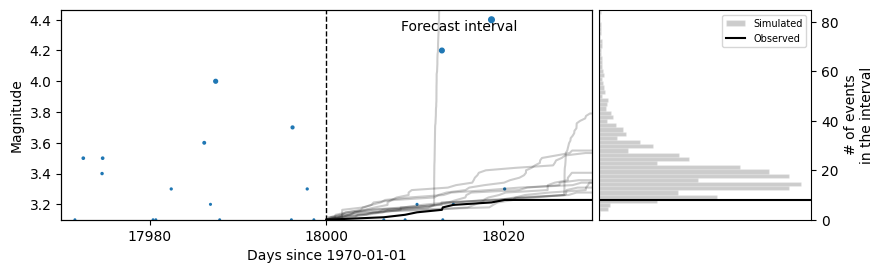

In [46]:
date_str = catalog_ds.metadata['start_ts'].strftime('%Y-%m-%d')
src.utils.visualization.visualize_trajectories(test_seq, all_forecasts,save_path=checkpoint_dir/"all_forecasts.pdf",figsize=(10,3),xlabel='Days since '+date_str)
# src.utils.visualization.visualize_trajectories(train_seq, all_forecasts,save_path=checkpoint_dir/"all_forecasts.png")

N-test

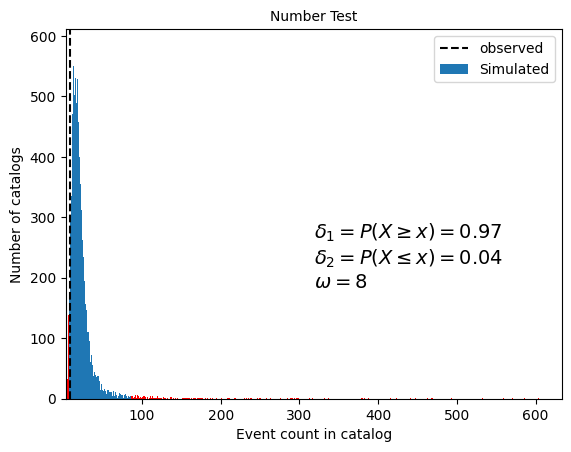

In [47]:
import  src.utils.catalog_tests as catalog_tests
number_test_result = catalog_tests.run_number_test_result(
    event_counts=[len(fc) for fc in all_forecasts],
    obs_count=len(observed_seq),                   
    min_mw=catalog_ds.metadata['mag_completeness'],
    obs_name='observed',
    sim_name='Simulated',
    plot=False
)
ax= number_test_result.plot(plot_args={'figsize':(6.4,4.8),'tight_layout':False})
plt.savefig(checkpoint_dir/'n_test.pdf')

In [48]:
all_forecasts

[Sequence(
   inter_times: [223],
   arrival_times: [222],
   t_start: 18000.0,
   t_end: 18030.0,
   t_nll_start: 18000.0,
   mag: [222]
 ),
 Sequence(
   inter_times: [28],
   arrival_times: [27],
   t_start: 18000.0,
   t_end: 18030.0,
   t_nll_start: 18000.0,
   mag: [27]
 ),
 Sequence(
   inter_times: [14],
   arrival_times: [13],
   t_start: 18000.0,
   t_end: 18030.0,
   t_nll_start: 18000.0,
   mag: [13]
 ),
 Sequence(
   inter_times: [20],
   arrival_times: [19],
   t_start: 18000.0,
   t_end: 18030.0,
   t_nll_start: 18000.0,
   mag: [19]
 ),
 Sequence(
   inter_times: [29],
   arrival_times: [28],
   t_start: 18000.0,
   t_end: 18030.0,
   t_nll_start: 18000.0,
   mag: [28]
 ),
 Sequence(
   inter_times: [16],
   arrival_times: [15],
   t_start: 18000.0,
   t_end: 18030.0,
   t_nll_start: 18000.0,
   mag: [15]
 ),
 Sequence(
   inter_times: [44],
   arrival_times: [43],
   t_start: 18000.0,
   t_end: 18030.0,
   t_nll_start: 18000.0,
   mag: [43]
 ),
 Sequence(
   inter_time

M-test

In [49]:
config_dict = {
    'min_mw': catalog_ds.metadata['mag_completeness'],
    'max_mw': 10,
    'dmw': 0.01
}

magnitude_bins, distribution = catalog_tests.compute_magnitude_distribution(
    forecast[0].mag.cpu().numpy(), 
   **config_dict
)

In [50]:
import matplotlib
importlib.reload(src.utils.catalog_tests)

<module 'src.utils.catalog_tests' from '/root/autodl-tmp/chuandian_eq/src/utils/catalog_tests.py'>

In [51]:
observed_seq    

Sequence(
  inter_times: [9],
  arrival_times: [8],
  t_start: 18000.0,
  t_end: 18030.001,
  t_nll_start: 18000.0,
  mag: [8],
  loc: [8, 2],
  depth: [8]
)

In [52]:
get_counts = functools.partial(catalog_tests.compute_magnitude_distribution, **config_dict)
result_dict = catalog_tests.magnitude_test_from_counts(
    observed_catalog=observed_seq,
    forecast_catalogs=all_forecasts,
    get_counts=lambda cat: get_counts(np.asarray(cat.mag.cpu()))[1],
    verbose=False,  
    debug=False
)


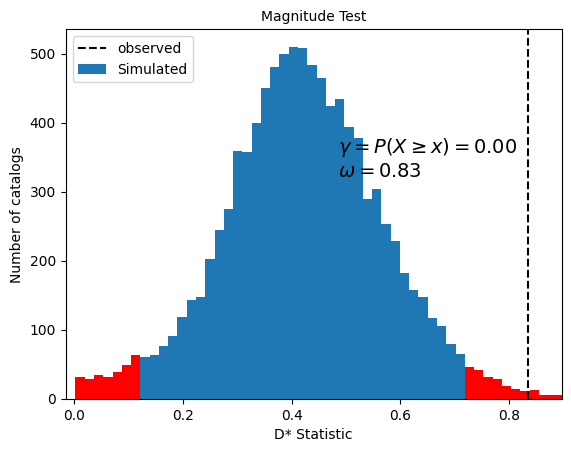

In [53]:
magnitude_test_result = catalog_tests.run_magnitude_test_result(
    result_dict=result_dict,
    obs_catalog_repr='obs',
   obs_name='observed',
    sim_name='Simulated',
    plot=False
)
magnitude_test_result.plot(plot_args={'figsize':(6.4,4.8),'tight_layout':False})
plt.savefig(checkpoint_dir/'m_test.pdf')

In [54]:
checkpoint_dir

PosixPath('../checkpoints/etas_20260103-143159')